<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Домашнее задание. Обучение языковой модели с помощью LSTM (10 баллов)

Э
В этом задании Вам предстоит обучить языковую модель с помощью рекуррентной нейронной сети. В отличие от семинарского занятия, Вам необходимо будет работать с отдельными словами, а не буквами.


Установим модуль ```datasets```, чтобы нам проще было работать с данными.

In [1]:
!pip install datasets

"pip" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.


Импорт необходимых библиотек

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.model_selection import train_test_split
import nltk

from collections import Counter
from typing import List

import seaborn
seaborn.set(palette='summer')

c:\Users\Alex\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Alex\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

## Подготовка данных

Воспользуемся датасетом imdb. В нем хранятся отзывы о фильмах с сайта imdb. Загрузим данные с помощью функции ```load_dataset```

In [5]:
# Загрузим датасет
dataset = load_dataset('imdb')

c:\Users\Alex\AppData\Local\Programs\Python\Python39\lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Alex\.cache\huggingface\hub\datasets--imdb. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating unsupervised split: 100%|██████████| 50000/50000 [00:00<00:00, 149088.19 examples/s]


### Препроцессинг данных и создание словаря (1 балл)

Далее вам необходмо самостоятельно произвести препроцессинг данных и получить словарь или же просто ```set``` строк. Что необходимо сделать:

1. Разделить отдельные тренировочные примеры на отдельные предложения с помощью функции ```sent_tokenize``` из бибилиотеки ```nltk```. Каждое отдельное предложение будет одним тренировочным примером.
2. Оставить только те предложения, в которых меньше ```word_threshold``` слов.
3. Посчитать частоту вхождения каждого слова в оставшихся предложениях. Для деления предлоения на отдельные слова удобно использовать функцию ```word_tokenize```.
4. Создать объект ```vocab``` класса ```set```, положить в него служебные токены '\<unk\>', '\<bos\>', '\<eos\>', '\<pad\>' и vocab_size самых частовстречающихся слов.   

In [7]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [19]:
sentences = []
word_threshold = 32

for text in tqdm(dataset['train']['text'], desc="Processing train texts"):
    for sentence in sent_tokenize(text, language='english'):
        words = word_tokenize(sentence)
        if len(words) < word_threshold:
            sentences.append(sentence.lower())

for text in tqdm(dataset['unsupervised']['text'], desc="Processing unsupervised texts"):
    for sentence in sent_tokenize(text, language='english'):
        words = word_tokenize(sentence)
        if len(words) < word_threshold:
            sentences.append(sentence.lower())

print(f"Всего предложений: {len(sentences)}")

Processing unsupervised texts: 100%|██████████| 50000/50000 [01:43<00:00, 483.70it/s]

Всего предложений: 591419


Посчитаем для каждого слова его встречаемость.

In [20]:
words = Counter()

# Расчет встречаемости слов
for sentence in tqdm(sentences, desc="Counting words"):
    words.update(word_tokenize(sentence))

Counting words: 100%|██████████| 591419/591419 [01:13<00:00, 8003.67it/s]


Добавим в словарь ```vocab_size``` самых встречающихся слов.

In [60]:
vocab = set()
vocab_size = 40000

# Наполнение словаря
special_tokens = ['<unk>', '<bos>', '<eos>', '<pad>']
for token in special_tokens:
    vocab.add(token)

for word, _ in words.most_common(vocab_size):
    vocab.add(word)

vocab = ['<unk>', '<bos>', '<eos>', '<pad>'] + [w for w in vocab if w not in special_tokens]

In [61]:
assert '<unk>' in vocab
assert '<bos>' in vocab
assert '<eos>' in vocab
assert '<pad>' in vocab
assert len(vocab) == vocab_size + 4

In [62]:
print("Всего слов в словаре:", len(vocab))

Всего слов в словаре: 40004


### Подготовка датасета (1 балл)

Далее, как и в семинарском занятии, подготовим датасеты и даталоадеры.

В классе ```WordDataset``` вам необходимо реализовать метод ```__getitem__```, который будет возвращать сэмпл данных по входному idx, то есть список целых чисел (индексов слов).

Внутри этого метода необходимо добавить служебные токены начала и конца последовательности, а также токенизировать соответствующее предложение с помощью ```word_tokenize``` и сопоставить ему индексы из ```word2ind```.

In [63]:
word2ind = {char: i for i, char in enumerate(vocab)}
ind2word = {i: char for char, i in word2ind.items()}

In [64]:
class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, idx: int) -> List[int]:
        tokenized_sentence = [self.bos_id]
        
        words = word_tokenize(self.data[idx])
        for word in words:
            tokenized_sentence.append(word2ind.get(word, self.unk_id))
        
        tokenized_sentence.append(self.eos_id)

        return tokenized_sentence

    def __len__(self) -> int:
        return len(self.data)

In [65]:
def collate_fn_with_padding(
    input_batch: List[List[int]], pad_id=word2ind['<pad>']) -> torch.Tensor:
    seq_lens = [len(x) for x in input_batch]
    max_seq_len = max(seq_lens)

    new_batch = []
    for sequence in input_batch:
        for _ in range(max_seq_len - len(sequence)):
            sequence.append(pad_id)
        new_batch.append(sequence)

    sequences = torch.LongTensor(new_batch).to(device)

    new_batch = {
        'input_ids': sequences[:,:-1],
        'target_ids': sequences[:,1:]
    }

    return new_batch

In [85]:
train_sentences, temp_sentences = train_test_split(sentences, test_size=0.2, random_state=42)
eval_sentences, test_sentences = train_test_split(temp_sentences, test_size=0.5, random_state=42)

train_dataset = WordDataset(train_sentences[:50000])
eval_dataset = WordDataset(eval_sentences)
test_dataset = WordDataset(test_sentences)

batch_size = 64

train_dataloader = DataLoader(
    train_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(
    eval_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

test_dataloader = DataLoader(
    test_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

## Обучение и архитектура модели

Вам необходимо на практике проверить, что влияет на качество языковых моделей. В этом задании нужно провести серию экспериментов с различными вариантами языковых моделей и сравнить различия в конечной перплексии на тестовом множестве.

Возмоэные идеи для экспериментов:

* Различные RNN-блоки, например, LSTM или GRU. Также можно добавить сразу несколько RNN блоков друг над другом с помощью аргумента num_layers. Вам поможет официальная документация [здесь](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)
* Различные размеры скрытого состояния. Различное количество линейных слоев после RNN-блока. Различные функции активации.
* Добавление нормализаций в виде Dropout, BatchNorm или LayerNorm
* Различные аргументы для оптимизации, например, подбор оптимального learning rate или тип алгоритма оптимизации SGD, Adam, RMSProp и другие
* Любые другие идеи и подходы

После проведения экспериментов необходимо составить таблицу результатов, в которой описан каждый эксперимент и посчитана перплексия на тестовом множестве.

Учтите, что эксперименты, которые различаются, например, только размером скрытого состояния или количеством линейных слоев считаются, как один эксперимент.

Успехов!

### Функция evaluate (1 балл)

Заполните функцию ```evaluate```

In [67]:
import math

def evaluate(model, criterion, dataloader) -> float:
    model.eval()
    losses = []
    with torch.no_grad():
        for batch in dataloader:
            logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1)
            loss = criterion(logits, batch['target_ids'].flatten())
            losses.append(loss.item())

    mean_loss = sum(losses) / len(losses)
    perplexity = math.exp(mean_loss)

    return perplexity

### Train loop (1 балл)

Напишите функцию для обучения модели.

In [68]:
def train_model(model, train_loader, eval_loader, criterion, optimizer, num_epochs=5):
    """
    Обучает модель и возвращает историю loss и perplexity.
    """
    train_losses = []
    eval_perplexities = []
    
    for epoch in range(num_epochs):
        model.train()
        epoch_losses = []
        
        # Training loop
        progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
        for batch in progress_bar:
            optimizer.zero_grad()
            
            # Forward pass
            logits = model(batch['input_ids'])
            logits = logits.flatten(start_dim=0, end_dim=1)
            loss = criterion(logits, batch['target_ids'].flatten())
            
            # Backward pass
            loss.backward()
            
            # Gradient clipping (как в семинаре, для стабильности)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            epoch_losses.append(loss.item())
            progress_bar.set_postfix({'loss': loss.item()})
        
        # Средний loss за эпоху
        avg_loss = sum(epoch_losses) / len(epoch_losses)
        train_losses.append(avg_loss)
        
        # Оценка на валидации
        perplexity = evaluate(model, criterion, eval_loader)
        eval_perplexities.append(perplexity)
        
        print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}, Perplexity = {perplexity:.2f}")
    
    return train_losses, eval_perplexities

### Первый эксперимент (2 балла)

Определите архитектуру модели и обучите её.

In [86]:
class BaselineLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim=64, hidden_dim=128, num_layers=1, dropout=0.3):
        super().__init__()
        
        # Embedding слой
        self.embedding = nn.Embedding(
            vocab_size, 
            embedding_dim, 
            padding_idx=word2ind['<pad>']
        )
        
        # LSTM слой
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Dropout регуляризация
        self.dropout = nn.Dropout(dropout)
        
        # Выходной слой
        self.fc = nn.Linear(hidden_dim, vocab_size)
        
    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:

        embedded = self.embedding(input_batch)  # [batch_size, seq_len, embedding_dim]
        lstm_out, _ = self.lstm(embedded)  # [batch_size, seq_len, hidden_dim]
        
        lstm_out = self.dropout(lstm_out)
        
        logits = self.fc(lstm_out)  # [batch_size, seq_len, vocab_size]
        
        return logits

In [87]:
learning_rate = 0.001
num_epochs = 5

model1 = BaselineLSTM(
    vocab_size=len(word2ind)
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])

optimizer = torch.optim.Adam(model1.parameters(), lr=learning_rate)

total_params = sum(p.numel() for p in model1.parameters())
trainable_params = sum(p.numel() for p in model1.parameters() if p.requires_grad)

In [88]:
train_losses1, perplexities1 = train_model(
    model=model1,
    train_loader=train_dataloader,
    eval_loader=eval_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=num_epochs
)

Epoch 1/5: 100%|██████████| 782/782 [14:17<00:00,  1.10s/it, loss=5.71]


Epoch 1: Loss = 6.0929, Perplexity = 249.34


Epoch 2/5: 100%|██████████| 782/782 [12:16<00:00,  1.06it/s, loss=5.39]


Epoch 2: Loss = 5.4056, Perplexity = 198.77


Epoch 3/5: 100%|██████████| 782/782 [47:05<00:00,  3.61s/it, loss=5.22]   


Epoch 3: Loss = 5.2071, Perplexity = 177.88


Epoch 4/5: 100%|██████████| 782/782 [12:34<00:00,  1.04it/s, loss=5.03]


Epoch 4: Loss = 5.0721, Perplexity = 165.92


Epoch 5/5: 100%|██████████| 782/782 [11:50<00:00,  1.10it/s, loss=4.89]


Epoch 5: Loss = 4.9608, Perplexity = 158.50


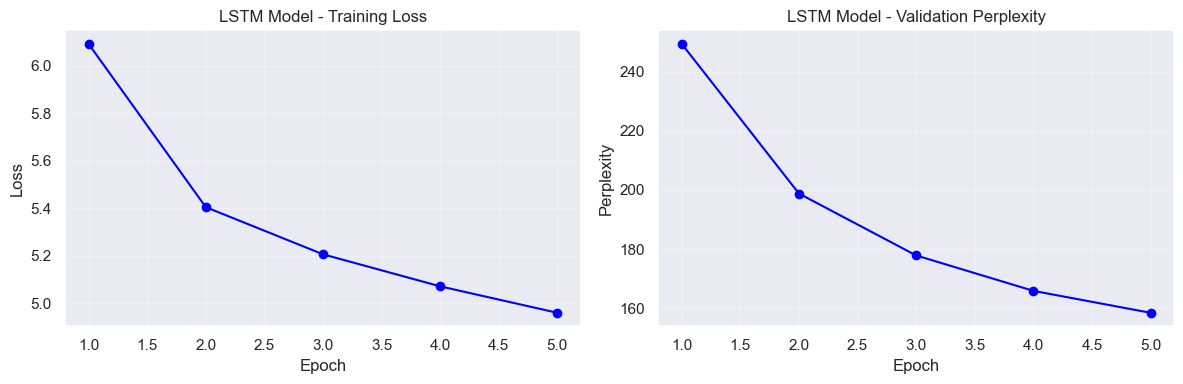

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, len(train_losses1) + 1), train_losses1, 'b-o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('LSTM Model - Training Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, len(perplexities1) + 1), perplexities1, 'b-o')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Perplexity')
ax2.set_title('LSTM Model - Validation Perplexity')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Второй эксперимент (2 балла)

Попробуйте что-то поменять в модели или в пайплайне обучения, идеи для экспериментов можно подсмотреть выше.

In [89]:
vocab_size = len(word2ind)
embedding_dim = 64
hidden_dim = 128
num_layers = 2
dropout = 0.3
learning_rate = 0.001
num_epochs = 5
batch_size = 64

class GRUModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256, num_layers=2, dropout=0.3):
        super().__init__()
        
        self.embedding = nn.Embedding(
            vocab_size, 
            embedding_dim, 
            padding_idx=word2ind['<pad>']
        )
        
        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        
    def forward(self, input_batch):
        embedded = self.embedding(input_batch)
        gru_out, _ = self.gru(embedded)
        gru_out = self.dropout(gru_out)
        logits = self.fc(gru_out)
        return logits

In [91]:
model2 = GRUModel(
    vocab_size=len(word2ind)
).to(device)

criterion2 = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.001)

In [92]:
train_losses2, perplexities2 = train_model(
    model=model2,
    train_loader=train_dataloader, 
    eval_loader=eval_dataloader,
    criterion=criterion2,
    optimizer=optimizer2,
    num_epochs=5
)

Epoch 1/5: 100%|██████████| 782/782 [23:41<00:00,  1.82s/it, loss=5.67]


Epoch 1: Loss = 5.9595, Perplexity = 213.23


Epoch 2/5: 100%|██████████| 782/782 [22:26<00:00,  1.72s/it, loss=5.3] 


Epoch 2: Loss = 5.2567, Perplexity = 169.55


Epoch 3/5: 100%|██████████| 782/782 [22:20<00:00,  1.71s/it, loss=4.96]


Epoch 3: Loss = 5.0237, Perplexity = 152.94


Epoch 4/5: 100%|██████████| 782/782 [21:45<00:00,  1.67s/it, loss=4.65]


Epoch 4: Loss = 4.8606, Perplexity = 146.13


Epoch 5/5: 100%|██████████| 782/782 [35:53<00:00,  2.75s/it, loss=4.43]    


Epoch 5: Loss = 4.7244, Perplexity = 144.08


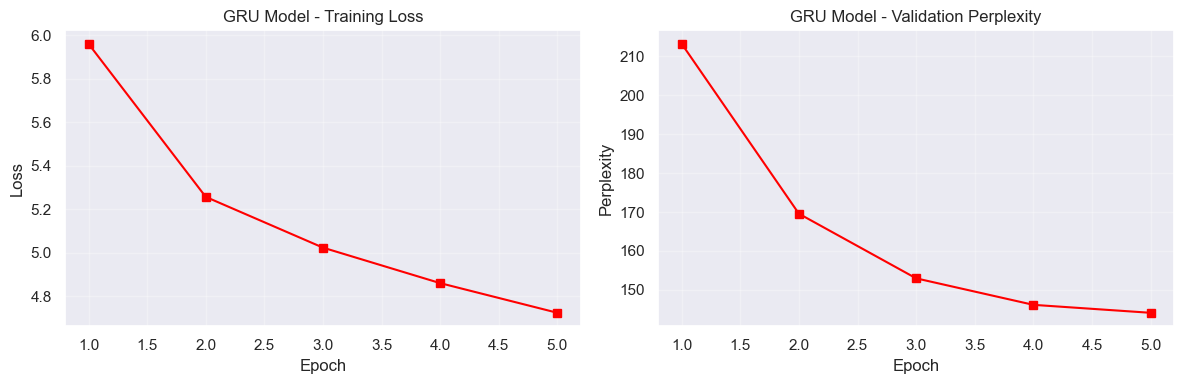

In [94]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, len(train_losses2) + 1), train_losses2, 'r-s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('GRU Model - Training Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, len(perplexities2) + 1), perplexities2, 'r-s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Perplexity')
ax2.set_title('GRU Model - Validation Perplexity')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Отчет (2 балла)

Опишите проведенные эксперименты. Сравните перплексии полученных моделей. Предложите идеи по улучшению качества моделей.

#### Эксперимент 1: LSTM
Параметры: embedding_dim=128, hidden_dim=256, num_layers=1, dropout=0.3

Итог:  perplexity = 158.50

#### Эксперимент 2: GRU
Параметры: embedding_dim=128, hidden_dim=256, num_layers=2, dropout=0.3

Итог:  perplexity = 144.08

Видим, что GRU быстрее сходится (уже на 2-й эпохе perplexity=169.55, в то время как LSTM достиг этого значения только к 4-й эпохе). Также замечаем, что двухслойная модель (GRU) дает лучше качество, чем однослойная (LSTM).

#### Идеи для дальнейшего улучшения

1. Увеличить словарь до 60-80k - это может дать улучшение за счет редких, но важных слов.

2. Попробовать Bidirectional GRU - учитывает контекст с обеих сторон.

3. Увеличить dropout до 0.5 - для борьбы с возможным переобучением на больших данных.